In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import supervision as sv
from pathlib import Path

DIR_ACTUAL = Path.cwd()
DIR_IMAGEN = DIR_ACTUAL / "assets/fotos/futbot-03.png"
image_bgr = cv2.imread(str(DIR_IMAGEN))
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

SOURCE_POINTS = np.float32([[205, 100], [875, 100], [1000, 500], [90, 500]])
CAMPO_W, CAMPO_H = 486, 364
ESCALA_PX_CM = 2.0  # 1 cm real = 2 px en el campo canónico (RCJ SF23: 182 × 243 cm)
TARGET_POINTS = np.float32([[0, 0], [CAMPO_W, 0], [CAMPO_W, CAMPO_H], [0, CAMPO_H]])
H = cv2.getPerspectiveTransform(SOURCE_POINTS, TARGET_POINTS)

CLASS_NAMES = {0: "azul", 1: "rojo", 2: "pelota"}
COLORS_HEX  = {0: "#00b4d8", 1: "#ef233c", 2: "#ff9500"}
COLORS_BGR  = {0: (216, 180, 0), 1: (60, 35, 239), 2: (0, 149, 255)}

print(f"Imagen: {image_bgr.shape[1]}×{image_bgr.shape[0]} px | H: {H.shape}")

Imagen: 1080×601 px | H: (3, 3)


In [3]:
def detect_robots_hsv(frame_bgr: np.ndarray,
                      min_area: int = 500) -> sv.Detections:
    """
    Detecta robots y balón en un frame usando filtros de color HSV.
    Devuelve sv.Detections con class_id: 0=azul, 1=rojo, 2=balón.
    """
    hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)

    mask_azul = cv2.inRange(hsv, np.array([100, 100, 100]),
                                 np.array([140, 255, 255]))
    mask_rojo = cv2.inRange(hsv, np.array([  0, 100, 100]),
                                 np.array([ 10, 255, 255]))
    mask_balon = cv2.inRange(hsv, np.array([ 15, 100, 100]),
                                  np.array([ 20, 255, 255]))

    xyxy_list, class_ids = [], []
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    for mask, cid in [(mask_azul, 0), (mask_rojo, 1), (mask_balon, 2)]:
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL,
                                       cv2.CHAIN_APPROX_SIMPLE)
        for cnt in contours:
            if cv2.contourArea(cnt) < min_area:
                continue
            x, y, w, h_box = cv2.boundingRect(cnt)
            xyxy_list.append([x, y, x + w, y + h_box])
            class_ids.append(cid)

    if not xyxy_list:
        return sv.Detections.empty()
    confidences = np.ones(len(xyxy_list), dtype=np.float32)
    return sv.Detections(
        xyxy=np.array(xyxy_list, dtype=np.float32),
        class_id=np.array(class_ids, dtype=int),
        confidence=confidences
    )

# Probar en la imagen estática
dets = detect_robots_hsv(image_bgr)
print(f"Detecciones encontradas: {len(dets)}")
for i, (box, cid) in enumerate(zip(dets.xyxy, dets.class_id)):
    cx = int((box[0] + box[2]) / 2)
    cy = int(box[3])
    print(f"  [{i}] {CLASS_NAMES[cid]:5s}: bbox={box.astype(int).tolist()}  bottom_center=({cx},{cy})")

Detecciones encontradas: 3
  [0] azul : bbox=[378, 265, 431, 324]  bottom_center=(404,324)
  [1] rojo : bbox=[530, 316, 583, 374]  bottom_center=(556,374)
  [2] pelota: bbox=[288, 237, 316, 265]  bottom_center=(302,265)


In [4]:
from ultralytics import SAM
dets_hsv = detect_robots_hsv(image_bgr)

sam_model = SAM("sam3.pt")
print("✅ SAM cargado")

# Obtener máscaras usando los bboxes del detector HSV como prompts
bboxes = dets_hsv.xyxy.tolist()
results = sam_model(image_bgr, bboxes=bboxes, verbose=False)
dets_sam = sv.Detections.from_ultralytics(results[0])

# Transferir class_id del detector HSV (SAM no conoce las clases)
if len(dets_sam) == len(dets_hsv):
    dets_sam.class_id = dets_hsv.class_id

print(f"Detecciones SAM: {len(dets_sam)}")
print(f"  Máscaras shape: {dets_sam.mask.shape if dets_sam.mask is not None else 'None'}")
print(f"  Dtype: {dets_sam.mask.dtype if dets_sam.mask is not None else 'None'}")

✅ SAM cargado
WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
Detecciones SAM: 3
  Máscaras shape: (3, 601, 1080)
  Dtype: bool


In [5]:
def project_mask_contour(mask: np.ndarray, H: np.ndarray) -> np.ndarray | None:
    """Proyecta el contorno exterior de una máscara al campo canónico."""
    contours, _ = cv2.findContours(mask.astype(np.uint8),
                                   cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    cnt = max(contours, key=cv2.contourArea)
    pts = cnt.reshape(-1, 1, 2).astype(np.float32)
    pts_proj = cv2.perspectiveTransform(pts, H)
    return pts_proj.reshape(-1, 2).astype(np.int32)


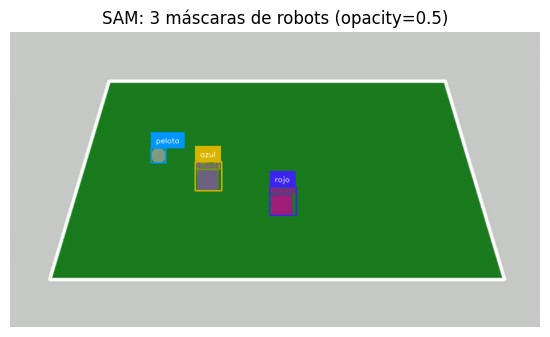

In [6]:
palette   = sv.ColorPalette.from_hex(list(COLORS_HEX.values()))
mask_ann  = sv.MaskAnnotator(color=palette, opacity=0.5)
box_ann   = sv.BoxAnnotator(color=palette, thickness=2)
label_ann = sv.LabelAnnotator(color=palette, text_color=sv.Color.WHITE)

class_ids = dets_sam.class_id if dets_sam.class_id is not None else []
labels = [CLASS_NAMES.get(int(c), "?") for c in class_ids]
vis = mask_ann.annotate(image_rgb.copy(), dets_sam)
vis = box_ann.annotate(vis, dets_sam)
vis = label_ann.annotate(vis, dets_sam, labels=labels)

plt.figure(figsize=(5.6, 10))
plt.imshow(vis)
plt.title(f"SAM: {len(dets_sam)} máscaras de robots (opacity=0.5)")
plt.axis("off")
plt.tight_layout()
plt.show()

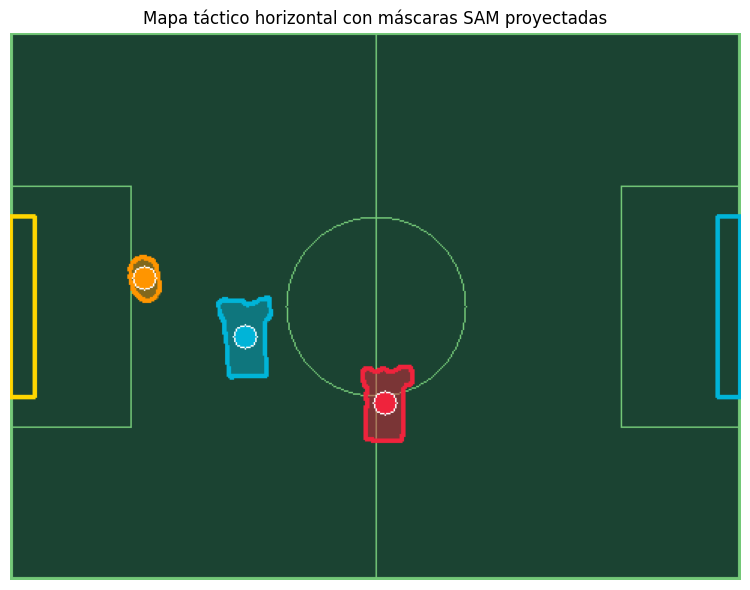

In [7]:
def draw_tactical_with_masks(dets_sam: sv.Detections, H: np.ndarray,
                                       campo_w: int = CAMPO_W, campo_h: int = CAMPO_H) -> np.ndarray:
    """Dibuja el mapa táctico HORIZONTAL con rellenos y contornos de máscaras SAM proyectadas."""

    ancho, alto = max(campo_w, campo_h), min(campo_w, campo_h)
    
    canvas = np.zeros((alto, ancho, 3), dtype=np.uint8)
    canvas[:] = (50, 67, 27)

    # 1. Líneas perimetrales del campo
    cv2.rectangle(canvas, (0, 0), (ancho - 1, alto - 1), (120, 200, 116), 2)
    
    # 2. Línea media (ahora es una línea vertical que divide el ancho)
    cv2.line(canvas, (ancho // 2, 0), (ancho // 2, alto), (120, 200, 116), 1)
    
    # 3. Círculo central
    cv2.circle(canvas, (ancho // 2, alto // 2), int(30 * ESCALA_PX_CM), (120, 200, 116), 1)
    
    # 4. Áreas grandes (ahora en los extremos izquierdo y derecho)
    pen_w = int(40 * ESCALA_PX_CM)  # Profundidad del área hacia el centro
    pen_h = int(80 * ESCALA_PX_CM)  # Ancho vertical del área
    pen_y = (alto - pen_h) // 2
    
    # Área izquierda
    cv2.rectangle(canvas, (0, pen_y), (pen_w, pen_y + pen_h), (120, 200, 116), 1)
    # Área derecha
    cv2.rectangle(canvas, (ancho - pen_w, pen_y), (ancho - 1, pen_y + pen_h), (120, 200, 116), 1)
    
    # 5. Porterías (Extremo izquierdo y derecho)
    goal_hp = int(60 * ESCALA_PX_CM)  # Alto vertical de la portería
    goal_yp = (alto - goal_hp) // 2
    goal_depth = int(8 * ESCALA_PX_CM) # Profundidad de la red hacia afuera/adentro
    
    # Portería izquierda (azul)
    cv2.rectangle(canvas, (0, goal_yp), (goal_depth, goal_yp + goal_hp), (0, 214, 255), 2)
    # Portería derecha (amarilla)
    cv2.rectangle(canvas, (ancho - goal_depth, goal_yp), (ancho - 1, goal_yp + goal_hp), (216, 180, 0), 2)

    masks     = dets_sam.mask
    class_ids = (dets_sam.class_id if dets_sam.class_id is not None
                 else np.zeros(len(dets_sam), dtype=int))

    if masks is not None:
        for m, cid in zip(masks, class_ids):
            color = COLORS_BGR.get(int(cid), (200, 200, 200))

            # Opción A: relleno semitransparente (warp de la máscara)
            m_uint8  = m.astype(np.uint8) * 255
            m_warped = cv2.warpPerspective(m_uint8, H, (ancho, alto))
            overlay  = canvas.copy()
            overlay[m_warped > 0] = color
            canvas = cv2.addWeighted(overlay, 0.45, canvas, 0.55, 0)

            # Opción B: contorno proyectado
            contorno = project_mask_contour(m, H)
            if contorno is not None and len(contorno) > 2:
                cv2.polylines(canvas, [contorno], True, color, 2)

            # Centroide de la máscara
            ys, xs = np.where(m)
            if len(xs) > 0:
                cx = int(xs.mean()); cy = int(ys.mean())
                pt = np.float32([[[cx, cy]]])
                proj = cv2.perspectiveTransform(pt, H)
                px, py = int(proj[0][0][0]), int(proj[0][0][1])
                if 0 <= px < ancho and 0 <= py < alto:
                    cv2.circle(canvas, (px, py), 8, color, -1)
                    cv2.circle(canvas, (px, py), 8, (255, 255, 255), 1)

    return canvas

tactical_bgr = draw_tactical_with_masks(dets_sam, H)

plt.figure(figsize=(8.0, 6.0))
plt.imshow(cv2.cvtColor(tactical_bgr, cv2.COLOR_BGR2RGB))
plt.title("Mapa táctico horizontal con máscaras SAM proyectadas")
plt.axis("off")
plt.tight_layout()
plt.show()

In [8]:
def callback_nb12(frame: np.ndarray, _: int) -> np.ndarray:
    # 1. Detección HSV
    dets = detect_robots_hsv(frame)
    if len(dets) == 0:
        escala  = CAMPO_H / frame.shape[0]
        resized = cv2.resize(frame, (int(frame.shape[1] * escala), CAMPO_H))
        blank   = np.zeros((CAMPO_H, CAMPO_W, 3), dtype=np.uint8); blank[:] = (50, 67, 27)
        return np.hstack([resized, blank, blank])

    # 2. SAM con bboxes como prompts
    results  = sam_model(frame, bboxes=dets.xyxy.tolist(), verbose=False)
    dets_sam = sv.Detections.from_ultralytics(results[0])
    if len(dets_sam) == len(dets):
        dets_sam.class_id = dets.class_id

    # 3. Vista cenital
    warped = cv2.warpPerspective(frame, H, (CAMPO_W, CAMPO_H))

    # 4. Mapa táctico con máscaras
    tactical = draw_tactical_with_masks(dets_sam, H)

    if dets_sam.mask is not None:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame_rgb = sv.MaskAnnotator(opacity=0.4).annotate(frame_rgb, dets_sam)
        frame_annotated = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
    else:
        frame_annotated = frame.copy()

    escala  = CAMPO_H / frame.shape[0]
    orig_w  = int(frame.shape[1] * escala)
    resized = cv2.resize(frame_annotated, (orig_w, CAMPO_H))

    return np.hstack([resized, warped, tactical])

INPUT_VIDEO = DIR_ACTUAL / 'assets/videos/futbot-3.mp4'
OUTPUT_VIDEO = DIR_ACTUAL / 'assets/videos/futbot-nb12.mp4'
sv.process_video(
    source_path=INPUT_VIDEO,
    target_path=OUTPUT_VIDEO,
    callback=callback_nb12,
)
print(f"✅ Video guardado: {OUTPUT_VIDEO}")

WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
WARNING imgsz=[1024] must

In [ ]:
cap = cv2.VideoCapture(OUTPUT_VIDEO)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frames_vis = {}
for idx in (0, n_frames // 2, n_frames - 1):
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    if ret:
        frames_vis[idx] = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
cap.release()

_sample = next(iter(frames_vis.values()))
_h, _w = _sample.shape[:2]
_dh = 4
fig, axes = plt.subplots(len(frames_vis), 1,
                         figsize=(_dh * _w / _h, _dh * len(frames_vis)))
titles = ["Frame inicial", "Frame central", "Frame final"]
for ax, (idx, frgb), title in zip(axes, frames_vis.items(), titles):
    ax.imshow(frgb)
    ax.set_title(f"{title} — orig | cenital | máscaras")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# RETO RESUELTO: mapa de calor de control por equipo

def build_heatmap(video_path: str, sam_model, H: np.ndarray,
                  campo_w: int = CAMPO_W, campo_h: int = CAMPO_H,
                  max_frames: int = 24) -> dict:
    """
    Procesa los primeros max_frames del video y acumula la presencia
    de cada equipo en el campo canónico.
    Devuelve {class_id: ndarray (campo_h, campo_w) acumulado}.
    """
    heatmaps = {0: np.zeros((campo_h, campo_w), dtype=np.float32),
                1: np.zeros((campo_h, campo_w), dtype=np.float32)}
    cap = cv2.VideoCapture(video_path)
    frame_count = 0
    while frame_count < max_frames:
        ret, frame = cap.read()
        if not ret: break
        dets = detect_robots_hsv(frame)
        if len(dets) > 0:
            results  = sam_model(frame, bboxes=dets.xyxy.tolist(), verbose=False)
            dets_sam = sv.Detections.from_ultralytics(results[0])
            if len(dets_sam) == len(dets):
                dets_sam.class_id = dets.class_id
            if dets_sam.mask is not None:
                for m, cid in zip(dets_sam.mask, dets_sam.class_id or []):
                    if int(cid) in heatmaps:
                        m_w = cv2.warpPerspective(m.astype(np.uint8) * 255, H,
                                                  (campo_w, campo_h))
                        heatmaps[int(cid)] += m_w.astype(np.float32)
        frame_count += 1
    cap.release()
    # Normalizar a [0, 1]
    for cid in heatmaps:
        mx = heatmaps[cid].max()
        if mx > 0:
            heatmaps[cid] /= mx
    return heatmaps

print("Generando mapas de calor (primeros 24 frames)...")
heatmaps = build_heatmap("assets/futbot-2s.mp4", sam_model, H)

fig, axes = plt.subplots(1, 2, figsize=(8, 6))
for ax, (cid, hm) in zip(axes, heatmaps.items()):
    warped_rgb = cv2.cvtColor(
        cv2.warpPerspective(image_bgr, H, (CAMPO_W, CAMPO_H)),
        cv2.COLOR_BGR2RGB)
    ax.imshow(warped_rgb, alpha=0.4)
    cmap = "Blues" if cid == 0 else "Reds"
    ax.imshow(hm, alpha=0.6, cmap=cmap, vmin=0, vmax=1)
    ax.set_title(f"Equipo {CLASS_NAMES[cid]} — mapa de calor (24 frames)")
    ax.axis("off")
plt.suptitle("Control del campo a lo largo del video", fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
### Experimento 1: Centroide de máscara vs. centro de bounding box

# Comparar las dos posiciones para cada detección
print("Robot  |  Centro bbox (NB11)  |  Centroide máscara (NB12)  |  Diferencia")
print("─" * 72)
for i, (box, m) in enumerate(zip(dets_sam.xyxy, dets_sam.mask)):
    # NB11: bottom-center del bbox
    cx_box = (box[0] + box[2]) / 2; cy_box = box[3]
    proj_box = cv2.perspectiveTransform(np.float32([[[cx_box, cy_box]]]), H)
    pos_box  = (int(proj_box[0][0][0]), int(proj_box[0][0][1]))

    # NB12: centroide de la máscara
    ys, xs  = np.where(m)
    cx_m, cy_m = float(xs.mean()), float(ys.mean())
    proj_m  = cv2.perspectiveTransform(np.float32([[[cx_m, cy_m]]]), H)
    pos_m   = (int(proj_m[0][0][0]), int(proj_m[0][0][1]))

    diff = np.linalg.norm(np.array(pos_box) - np.array(pos_m))
    cid  = int(dets_sam.class_id[i]) if dets_sam.class_id is not None else 0
    print(f"  {CLASS_NAMES.get(cid,'?'):5s} | {str(pos_box):20s} | {str(pos_m):26s} | {diff:.1f} px")

# 💭 Reflexión: ¿en qué robots hay más diferencia entre los dos métodos?
# ¿El centroide de la máscara es siempre más preciso que el bottom-center?
# ¿Para qué tipo de análisis importa más esta diferencia?

Robot  |  Centro bbox (NB11)  |  Centroide máscara (NB12)  |  Diferencia
────────────────────────────────────────────────────────────────────────
  azul  | (159, 229)           | (156, 203)                 | 26.2 px
  rojo  | (250, 271)           | (249, 246)                 | 25.0 px
  pelota | (91, 178)            | (89, 164)                  | 14.1 px


In [ ]:
### Experimento 2: Área de cada robot en el campo canónico

print("Robot  | Área cámara | Área canónica | Ratio")
print("─" * 52)
for i, (m, cid) in enumerate(zip(dets_sam.mask, dets_sam.class_id or [])):
    m_uint8  = m.astype(np.uint8) * 255
    m_warped = cv2.warpPerspective(m_uint8, H, (CAMPO_W, CAMPO_H))
    area_cam   = int(m.sum())
    area_canon = int((m_warped > 0).sum())
    ratio = area_canon / area_cam if area_cam > 0 else 0
    print(f"  {CLASS_NAMES.get(int(cid),'?'):5s}  | {area_cam:11d} | {area_canon:13d} | {ratio:.3f}")

total_campo = CAMPO_W * CAMPO_H
print(f"\nÁrea total del campo canónico: {total_campo} px ({CAMPO_W}×{CAMPO_H})")

# 💭 Reflexión: ¿los robots más alejados de la cámara tienen menor área canónica?
# ¿Por qué el ratio difiere entre robots en distintas posiciones de la cancha?
# (Pista: la distorsión de perspectiva comprime las áreas lejanas al proyectarlas)

In [ ]:
### Experimento 3: ¿Cuánto campo controla cada equipo?

def team_control(dets_sam: sv.Detections, H: np.ndarray,
                 campo_w: int = CAMPO_W, campo_h: int = CAMPO_H) -> dict:
    """
    Calcula el % del campo canónico cubierto por cada equipo.
    Devuelve dict {class_id: porcentaje}.
    """
    masks     = dets_sam.mask
    class_ids = (dets_sam.class_id if dets_sam.class_id is not None
                 else np.zeros(len(dets_sam), dtype=int))
    total     = campo_w * campo_h
    areas     = {0: 0, 1: 0, 2: 0}

    if masks is not None:
        for m, cid in zip(masks, class_ids):
            m_warped = cv2.warpPerspective(m.astype(np.uint8) * 255, H,
                                           (campo_w, campo_h))
            areas[int(cid)] += int((m_warped > 0).sum())

    return {cid: round(area / total * 100, 3) for cid, area in areas.items()}

control = team_control(dets_sam, H)
print("Control del campo canónico por equipo/objeto:")
for cid, pct in control.items():
    bar = "█" * int(pct * 5)
    print(f"  {CLASS_NAMES.get(cid,'?'):5s}: {pct:6.3f}%  {bar}")

# 💭 Reflexión: esta métrica es el "% de zona controlada" que usan
# los analistas de fútbol profesional. ¿Qué limitaciones tiene
# calcularlo solo con la posición instantánea de un frame?